In [3]:
# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


from popy.simulation_tools import *
from popy.io_tools import load_behavior
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll
from popy.config import COLORS, PROJECT_PATH_LOCAL

In [9]:
model_renames = {
    'recording': lambda monkey: monkey,  # This will be handled specially
    #'Repeating agent': 'Repeating agent',
    'WSLS agent (long history)': 'WSLS',
    'Q-Learner': 'Standard RL',
    'Q-Learner counterfactual': 'Inferential RL',
    #'Shift-value agent': 'none',
    'Shift-value agent with reset': 'Foraging'
}


def load_fit_stats():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        if 'model' in res_temp.columns:
            res_temp = res_temp.rename(columns={'model': 'Model'})

        # add monkey name to the dataframe
        res_temp['monkey'] = monkey

        # rename models, remove those not in the renames dict
        res_temp = res_temp[res_temp['Model'].isin(model_renames.keys())]
        # replace model names according to the renames dict
        res_temp['Model'] = res_temp['Model'].replace(model_renames)

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

res_all = load_fit_stats()
res_all

,Unnamed: 0,monkey,Model,epsilon,alpha,beta,V0,LL_best,BIC_best,LPT_best,LL_CV,LL_std,BIC_CV,BIC_std,LPT_CV,LPT_std,Reward rate,Proba best
0,1,ka,WSLS,0.113738,NaN,NaN,NaN,-8732.021246,17474.122450,0.693524,-2929.674143,282.616361,5868.329633,565.232782,0.692162,0.024639,0.49737,0.57562
1,2,ka,Standard RL,NaN,0.520041,7.746170,NaN,-9215.603059,18451.366036,0.679610,-3076.160091,216.455033,6170.282875,432.910070,0.679411,0.018498,0.53974,0.69638
2,3,ka,Inferential RL,NaN,0.126673,8.706042,NaN,-12819.848035,25659.855987,0.584327,-4280.290610,339.265726,8578.543913,678.531542,0.584169,0.025172,0.53788,0.69482
3,5,ka,Foraging,NaN,0.408075,10.601215,0.118913,-5665.823889,11361.887654,0.788628,-1895.152127,178.457674,3817.248293,356.915499,0.788112,0.017759,0.54292,0.70755
4,1,po,WSLS,0.280936,NaN,NaN,NaN,-9934.153914,19877.933915,0.519181,-3317.320588,91.597615,6643.168649,183.195125,0.518627,0.009423,0.44833,0.44910
5,2,po,Standard RL,NaN,0.393628,3.749808,NaN,-11976.276876,23971.805923,0.453730,-4008.666381,179.338625,8034.387709,358.677041,0.452433,0.016048,0.50563,0.60303
6,3,po,Inferential RL,NaN,0.149893,4.613720,NaN,-12601.779874,25222.811920,0.435384,-4218.741365,269.353003,8454.537677,538.705898,0.434238,0.023517,0.49928,0.58866
7,5,po,Foraging,NaN,0.296439,6.956455,0.180686,-7833.732903,15696.344062,0.596362,-2620.424271,109.666350,5266.430963,219.332424,0.595372,0.012979,0.52059,0.64223


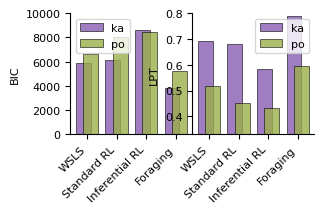

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set font size and figure size
plt.rcParams.update({'font.size': 8})
w, h = 8, 4

# Define the modes and figure
modes = ['BIC_CV', 'LPT_CV']
fig, axes = plt.subplots(1, 2, figsize=(w/2.54, h/2.54), gridspec_kw={'wspace': 0})

# Iterate over the modes and plot
for i, mode in enumerate(modes):
    ax = axes[i]
    
    '''# Create a bar plot directly from the DataFrame
    # Create a bar plot with overlapping bars
    sns.barplot(
        data=res_all.loc[res_all['monkey'] != 'yu_DCZ'],
        x='Model',
        y=mode,
        hue='monkey',
        palette=COLORS,
        ax=ax,
        edgecolor='black',
        linewidth=0.5,
        legend=True,
        dodge=0.1  # Adjust this value to control overlap (0.5-0.8 typically works well)
    )'''
    # Get unique values
    models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
    monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Set up positions
    x = np.arange(len(models))
    width = 0.5  # Width of bars
    offset = 0.25  # How much to offset for overlap

    for i, monkey in enumerate(monkeys):
        data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
        values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
        
        ax.bar(x + i*offset, values, width, 
            label=monkey, color=COLORS[monkey], 
            edgecolor='black', linewidth=0.5, alpha=0.8)
    
    # Configure axes
    ax.set_ylabel(mode)
    ax.set_xticks(x + offset/2)
    ax.set_xticklabels(models, rotation=45, horizontalalignment='right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend()
    
    # Set y-axis limits and labels based on the mode
    if mode == 'BIC_CV':
        ax.set_ylim(0, 10000)
        ax.set_ylabel('BIC', fontsize=8)
    elif mode == 'LPT_CV':
        ax.set_ylim(0.33, 0.80)
        ax.set_yticks(np.arange(0.4, 0.9, 0.1))
        ax.set_ylabel('LPT', fontsize=8)
        #ax.legend(title='Monkey', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig('figs/lpt.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()